In [1]:
# Extracting cell embeddings 
import numpy as np
import os
from geneformer import EmbExtractor
from geneformer import InSilicoPerturber
from geneformer import InSilicoPerturberStats
from geneformer import TranscriptomeTokenizer
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from datasets import load_from_disk
import pandas as pd
import h5py
from datasets import load_from_disk
import numpy as np


In [8]:


dataset = load_from_disk("/u/scratch/r/ramadas/geneformer_tokenized_data/Q_data_.dataset")

# Add cell_id column to the dataset to save place
cell_ids = np.arange(len(dataset))
dataset = dataset.add_column("cell_id", cell_ids)

# Verify the cell_id column was added
print("Updated column names:", dataset.column_names)
print("First few cell IDs:", dataset["cell_id"][:5])
print("First few cell IDs:", dataset['stimulation'][:10])


# Save the updated dataset back to disk
dataset.save_to_disk("/u/scratch/r/ramadas/geneformer_tokenized_data/Q_data_with_ids.dataset")

Dataset structure: Dataset({
    features: ['input_ids', 'stimulation', 'length'],
    num_rows: 47726
})
Column names: ['input_ids', 'stimulation', 'length']
Number of examples: 47726
Updated column names: ['input_ids', 'stimulation', 'length', 'cell_id']
First few cell IDs: [0, 1, 2, 3, 4]
First few cell IDs: ['rest', 'act', 'rest', 'rest', 'rest', 'act', 'rest', 'rest', 'act', 'rest']


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


  0%|          | 0/478 [00:00<?, ?it/s]

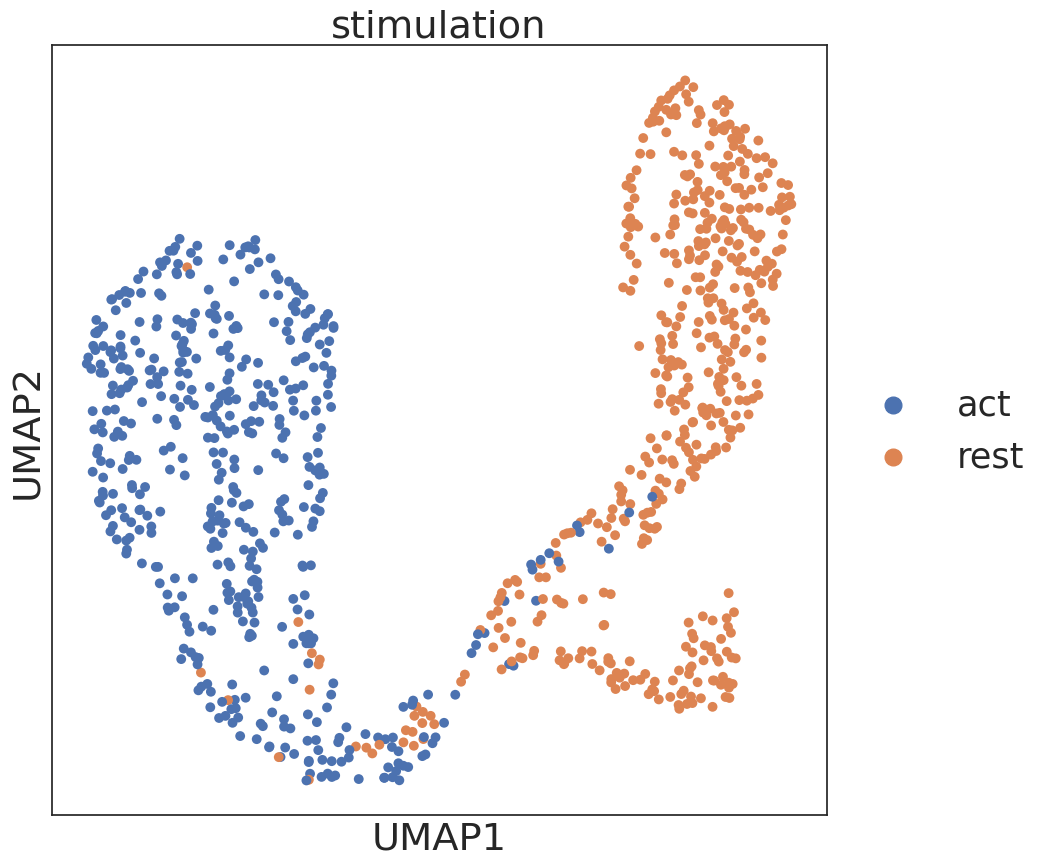

<Figure size 1000x1000 with 0 Axes>

In [11]:

# Make embs the file so dont have to run this all the time
embex = EmbExtractor(model_type="CellClassifier",
        num_classes=2,
        emb_mode="cell",
        max_ncells=47726,
        emb_layer=-1,
        emb_label=["stimulation", "cell_id"],  # Include cell_id
        labels_to_plot=["stimulation"]
)

# Extract embeddings using the new dataset with IDs
embs = embex.extract_embs(
    model_directory="/u/scratch/r/ramadas/geneformer_output/k5folds/250505142950/250505_geneformer_cellClassifier_cm_classifier_test/ksplit1/",
    input_data_file="/u/scratch/r/ramadas/geneformer_tokenized_data/Q_data_with_ids.dataset",  # Updated path
    output_directory="/u/scratch/r/ramadas/geneformer_models_res/k5folds/",
    output_prefix="data_embeddings_with_ids"
)

# Plot embeddings

embex.plot_embs(
    embs=embs,
    plot_style="umap",  # or "heatmap"
    output_directory="/u/scratch/r/ramadas/geneformer_models_res/k5folds/",
    output_prefix="data_embeddings_plot"
)



CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


  0%|          | 0/10 [00:00<?, ?it/s]

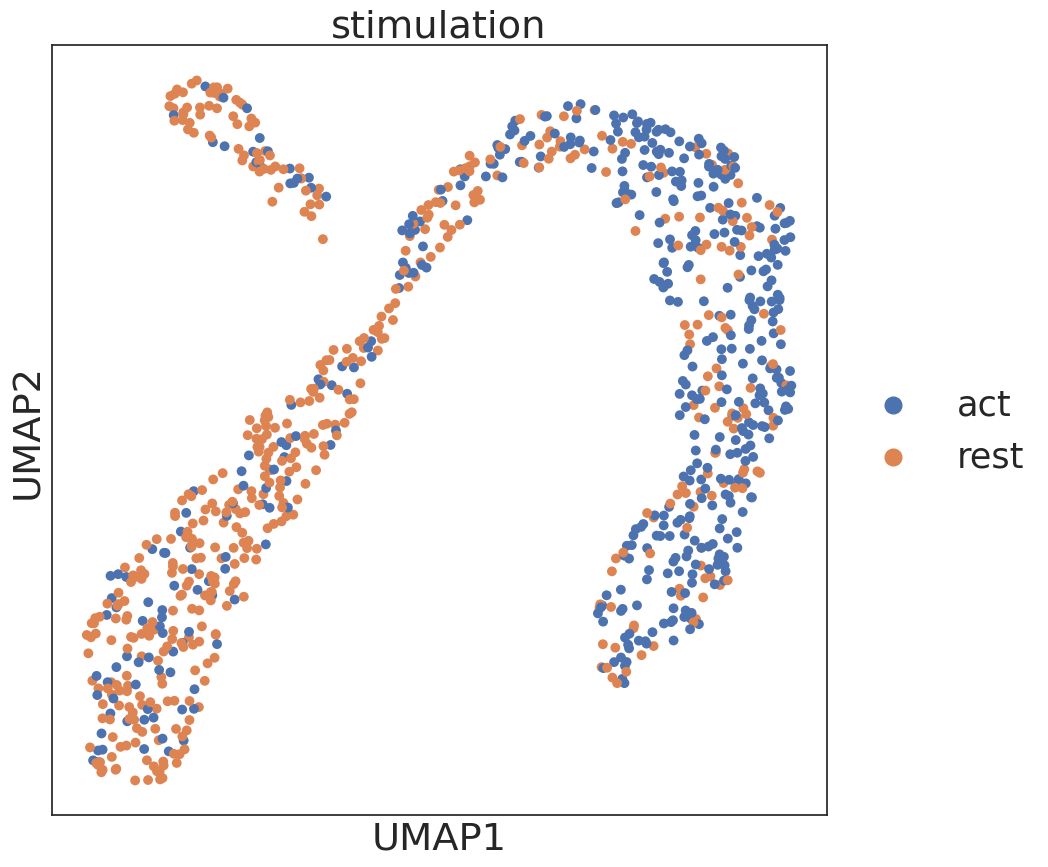

In [3]:
# Running Embeddings extraction on permuted data set

# Intializing embedding extractor
embex2 = EmbExtractor(model_type="CellClassifier",
        num_classes=2,
        emb_mode="cell",
        max_ncells=1000,
        emb_layer=-1,
        emb_label=["stimulation"],  # Add your relevant column labels
        labels_to_plot=["stimulation"]
)
# Extracting embeddings
embs2 = embex.extract_embs(
    model_directory="/u/scratch/r/ramadas/geneformer_output/k5folds/250331174823/250331_geneformer_cellClassifier_cm_classifier_test/ksplit1/",
    input_data_file="/u/home/r/ramadas/geneformer_tokenized_data/permuted/Q_data_permuted.dataset/",
    output_directory="/u/home/r/ramadas/geneformer_models_res/k5folds/",
    output_prefix="data_embeddings_permuted"
)

# Plot embeddings

embex2.plot_embs(
    embs=embs,
    plot_style="umap",  # or "heatmap"
    output_directory="/u/home/r/ramadas/geneformer_models_res/k5folds/",
    output_prefix="data_embeddings_plot_permuted"
)

In [15]:
# Load both files
data_embs = pd.read_csv("/u/scratch/r/ramadas/geneformer_models_res/k5folds/data_embeddings_with_ids.csv")

print("\nFirst 10 stimulation values in data_embeddings.csv:")
print(data_embs['stimulation'].head(10))
print(data_embs['cell_id'].head(10))

#Resort by cell_id for consistency

data_embs_sorted = data_embs.sort_values('cell_id')
data_embs_sorted = data_embs_sorted.reset_index(drop=True)
print("\nAfter sorting - first 5 rows:")
print(data_embs_sorted[['cell_id', 'stimulation']].head(10))

sorted_file_path = "/u/scratch/r/ramadas/geneformer_models_res/k5folds/data_embeddings_sorted.csv"
data_embs_sorted.to_csv(sorted_file_path, index=False)


First 10 stimulation values in data_embeddings.csv:
0    rest
1     act
2    rest
3    rest
4    rest
5     act
6     act
7    rest
8    rest
9    rest
Name: stimulation, dtype: object
0     0
1     1
2     2
3     3
4     4
5     5
6     8
7    10
8    11
9    15
Name: cell_id, dtype: int64

After sorting - first 5 rows:
   cell_id stimulation
0        0        rest
1        1         act
2        2        rest
3        3        rest
4        4        rest
5        5         act
6        6        rest
7        7        rest
8        8         act
9        9        rest


In [16]:
# Make embs the file so dont have to run this all the time
embs = pd.read_csv("/u/scratch/r/ramadas/geneformer_models_res/k5folds/data_embeddings_sorted.csv")

# Create relative distance of each cell's classification from decision boundary
# Going to train a simple linear classifier to get normalized distance from the decision boundary 
print(embs.shape)  
print(embs.columns) 
print(embs.head())

import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


X = embs.iloc[:, 0:255].values 
y = np.where(embs['stimulation'] == 'act', 1, 0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


svm = SVC(kernel='linear')
svm.fit(X_scaled, y)


raw_distances = svm.decision_function(X_scaled)
max_abs_distance = np.max(np.abs(raw_distances))
normalized_distances = raw_distances / max_abs_distance


embs['boundary_distance'] = normalized_distances

print("Distance statistics:")
print(f"Min distance: {embs['boundary_distance'].min()}")
print(f"Max distance: {embs['boundary_distance'].max()}")
print(f"Mean distance: {embs['boundary_distance'].mean()}")




(47726, 259)
Index(['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '248', '249', '250', '251', '252', '253', '254', '255', 'stimulation',
       'cell_id'],
      dtype='object', length=259)
   Unnamed: 0         0         1         2         3         4         5  \
0           0 -0.342523 -0.378004 -0.347549 -0.171031 -0.632680 -0.171840   
1           1 -0.116009  0.144605 -0.024363  0.138424  0.017319  0.007867   
2           2 -0.127409  0.143812 -0.003136  0.120233  0.005622  0.012849   
3           3 -0.191494  0.109573 -0.042712  0.124952 -0.130708  0.043136   
4           4 -0.335784 -0.505643 -0.420605 -0.230917 -0.695050 -0.117575   

          6         7         8  ...       248       249       250       251  \
0  0.464461  0.112516 -0.152370  ... -0.154529 -0.182277  0.032352  0.411230   
1  0.033888 -0.008516  0.203498  ...  0.116264  0.000776 -0.333545  0.036547   
2  0.025222 -0.009123  0.221023  ...  0.129492  0.019130 -0.337127  0.071038

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score

y_pred = svm.predict(X_scaled)
y_prob = svm.decision_function(X_scaled)  # For ROC-AUC


accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_prob)
conf_matrix = confusion_matrix(y, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)



Accuracy: 0.9644
Precision: 0.9652
Recall: 0.9648
F1 Score: 0.9650
ROC-AUC: 0.9835
Confusion Matrix:
[[22634   843]
 [  854 23395]]


In [20]:
print(embs['boundary_distance'].head(30))
print(embs['stimulation'].head(30))
outputfile = '/u/scratch/r/ramadas/geneformer_models_res/k5folds/data_embeddings_bound.csv'
embs.to_csv(outputfile)


0    -0.415800
1    -0.195274
2    -0.284387
3    -0.385035
4    -0.506675
5    -0.385726
6     0.007204
7    -0.590978
8    -0.378580
9     0.352616
10   -0.310154
11    0.102666
12   -0.373806
13   -0.149355
14   -0.452370
15   -0.455116
16   -0.063495
17   -0.431552
18   -0.473844
19   -0.464634
20   -0.459079
21   -0.473363
22    0.295394
23   -0.474206
24   -0.447274
25   -0.032505
26   -0.046619
27   -0.480947
28   -0.473249
29   -0.503050
Name: boundary_distance, dtype: float64
0     rest
1      act
2     rest
3     rest
4     rest
5      act
6     rest
7     rest
8      act
9     rest
10    rest
11    rest
12    rest
13    rest
14    rest
15    rest
16    rest
17    rest
18    rest
19    rest
20    rest
21    rest
22    rest
23    rest
24    rest
25    rest
26    rest
27    rest
28    rest
29    rest
Name: stimulation, dtype: object


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

# Load the data with boundary distances already calculated
embs = pd.read_csv("/u/scratch/r/ramadas/geneformer_models_res/k5folds/data_embeddings_sorted.csv")

# Extract features and labels
X = embs.iloc[:, 0:255].values
y = np.where(embs['stimulation'] == 'act', 1, 0)
boundary_distances = embs['boundary_distance']

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a figure
plt.figure(figsize=(10, 8))

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, (x_max - x_min) / 100),
                     np.arange(y_min, y_max, (y_max - y_min) / 100))

# Plot each class of points with color intensity based on boundary distance
class0_mask = y == 0
class1_mask = y == 1

# Normalize boundary distances for visualization (0 to 1 for each class)
dist_class0 = boundary_distances[class0_mask]
dist_class1 = boundary_distances[class1_mask]

# Create color maps for each class
blues = plt.cm.Blues(np.linspace(0.3, 1, 256))
reds = plt.cm.Reds(np.linspace(0.3, 1, 256))

# Convert distances to color indices (distance closer to boundary = lighter color)
# For class 0 (negative distances), map -1 to 0 (lightest) and smaller values to darker
# For class 1 (positive distances), map 1 to 255 (darkest) and smaller values to lighter
color_indices_0 = np.round(255 * (1 + dist_class0)).astype(int)
color_indices_1 = np.round(255 * dist_class1).astype(int)

# Plot points with colors based on distance from boundary
plt.scatter(X_pca[class0_mask, 0], X_pca[class0_mask, 1], 
            c=blues[color_indices_0], edgecolor='k', alpha=0.7, 
            label='Class 0 (Non-activated)')

plt.scatter(X_pca[class1_mask, 0], X_pca[class1_mask, 1], 
            c=reds[color_indices_1], edgecolor='k', alpha=0.7,
            label='Class 1 (Activated)')

# Plot the decision boundary (the line where boundary_distance = 0)
# We need to find points close to the boundary
boundary_mask = np.abs(boundary_distances) < 0.05
if np.any(boundary_mask):
    plt.scatter(X_pca[boundary_mask, 0], X_pca[boundary_mask, 1], 
                c='black', marker='x', s=50, label='Decision Boundary')

# Add a colorbar to show distance scale
sm_blue = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm_blue.set_array([])
cbar_blue = plt.colorbar(sm_blue, ax=plt.gca())
cbar_blue.set_label('Distance from boundary (Class 0)')

sm_red = plt.cm.ScalarMappable(cmap=plt.cm.Reds)
sm_red.set_array([])
cbar_red = plt.colorbar(sm_red, ax=plt.gca())
cbar_red.set_label('Distance from boundary (Class 1)')

# Add titles and labels
plt.title('SVM Decision Boundary Visualization\nColored by Distance from Decision Boundary')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Save the figure
plt.savefig('svm_decision_boundary.png', dpi=300, bbox_inches='tight')
plt.close()

print("Visualization saved as 'svm_decision_boundary.png'")

KeyError: 'boundary_distance'

In [3]:
# Perturbation of Cells using Selected Cells
# E2F1, HES1, FOXO3, and TFEB.
# have to convert to ensemble id
E2F1 = np.str_("ENSG00000101412")
HESL = np.str_("ENSG00000114315")
FOXO3 = np.str_("ENSG00000118689")
TFEB = np.str_("ENSG00000112561")


In [ ]:
genes_to_test = [E2F1]
isp = InSilicoPerturber(perturb_type="delete",
                       perturb_rank_shift=None,
                       genes_to_perturb= genes_to_test,
                       model_type="CellClassifier",
                       num_classes=2,
                       emb_mode="cls",
                       max_ncells=20,
                       emb_layer=0,
                       forward_batch_size=100,
                       nproc=16)


isp.perturb_data(
    model_directory="/u/scratch/r/ramadas/geneformer_output/k5folds/250331174823/250331_geneformer_cellClassifier_cm_classifier_test/ksplit1/",
    input_data_file="/u/home/r/ramadas/geneformer_tokenized_data/Q_data_.dataset",
    output_directory="/u/home/r/ramadas/geneformer_models_res/k5folds/E2F1/",
    output_prefix="attention_analysis"
)

In [4]:
genes_to_test = [HESL]
isp = InSilicoPerturber(perturb_type="delete",
                       perturb_rank_shift=None,
                       genes_to_perturb= genes_to_test,
                       model_type="CellClassifier",
                       num_classes=2,
                       emb_mode="cls",
                       max_ncells=20,
                       emb_layer=0,
                       forward_batch_size=100,
                       nproc=16)


isp.perturb_data(
    model_directory="/u/scratch/r/ramadas/geneformer_output/k5folds/250331174823/250331_geneformer_cellClassifier_cm_classifier_test/ksplit1/",
    input_data_file="/u/home/r/ramadas/geneformer_tokenized_data/Q_data_.dataset",
    output_directory="/u/home/r/ramadas/geneformer_models_res/k5folds/HESL/",
    output_prefix="attention_analysis"
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
genes_to_test = [FOXO3]
isp = InSilicoPerturber(perturb_type="delete",
                       perturb_rank_shift=None,
                       genes_to_perturb= genes_to_test,
                       model_type="CellClassifier",
                       num_classes=2,
                       emb_mode="cls",
                       max_ncells=20,
                       emb_layer=0,
                       forward_batch_size=100,
                       nproc=16)



isp.perturb_data(
    model_directory="/u/scratch/r/ramadas/geneformer_output/k5folds/250331174823/250331_geneformer_cellClassifier_cm_classifier_test/ksplit1/",
    input_data_file="/u/home/r/ramadas/geneformer_tokenized_data/Q_data_.dataset",
    output_directory="/u/home/r/ramadas/geneformer_models_res/k5folds/FOXO3/",
    output_prefix="attention_analysis"
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
genes_to_test = [TFEB]
isp = InSilicoPerturber(perturb_type="delete",
                       perturb_rank_shift=None,
                       genes_to_perturb= genes_to_test,
                       model_type="CellClassifier",
                       num_classes=2,
                       emb_mode="cls",
                       max_ncells=20,
                       emb_layer=0,
                       forward_batch_size=100,
                       nproc=16)

output_dir = "attention_weights_output"
os.makedirs(output_dir, exist_ok=True)

isp.perturb_data(
    model_directory="/u/scratch/r/ramadas/geneformer_output/k5folds/250331174823/250331_geneformer_cellClassifier_cm_classifier_test/ksplit1/",
    input_data_file="/u/home/r/ramadas/geneformer_tokenized_data/Q_data_.dataset",
    output_directory="/u/home/r/ramadas/geneformer_models_res/k5folds/TFEB/",
    output_prefix="attention_analysis"
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Results
ispstats = InSilicoPerturberStats(mode="goal_state_shift",
   cell_states_to_model={"state_key": "disease",
                         "start_state": "dcm",
                         "goal_state": "nf",
                         "alt_states": ["hcm", "other1", "other2"]})